In [2]:
#Reading out data and preprocesing
import scipy.io
data = scipy.io.loadmat('210921.mat')

spks = data['spks']
tc = data['tc']
cue = data['cueAng']
cueIdx = data['cueAngIdx']
corr = data['isCorr']

#print(spks.shape)
#print(tc.shape)
#print(cue.shape)
#print(cueIdx.shape)
#print(corr.shape)

corr = corr.flatten()
cueIdx = cueIdx.flatten()
#print(cueIdx.shape)
#print(corr.shape)
corr_bool = corr == 1
#print(corr_bool)

spks = spks[corr_bool]
cueIdx = cueIdx[corr_bool]
#print(spks.shape, cueIdx.shape)

In [3]:
#Discriminate cue to opposite cue
import numpy as np
#print(np.unique(cue))
target_cue = 4
opp_cue = 8

in48 = np.isin(cueIdx, [target_cue, opp_cue])
spks_48 = spks[in48]
cue_48 = cueIdx[in48]
#print(spks_48.shape, cue_48.shape)

y = (cue_48 == target_cue).astype(int) #Correct y
#print(y)

In [4]:
n_trials, n_time, n_neurons = spks_48.shape
new_time = n_time // 10
#To 10ms
spks_trim = spks_48[:, :new_time*10, :]

# Reshape 
spks_binned = spks_trim.reshape(n_trials, new_time, 10, n_neurons).sum(axis=2)

window = 10  # 100 ms
boxcar_kernel = np.ones(window) / window

spks_smooth = np.zeros_like(spks_binned)

for trial in range(n_trials):
    for neuron in range(n_neurons):
        spks_smooth[trial, :, neuron] = np.convolve(spks_binned[trial, :, neuron], boxcar_kernel, mode='same')


In [5]:
#Caculate z-score
z_score = np.zeros_like(spks_smooth)

for t in range(spks_smooth.shape[1]):
    mean = spks_smooth[:, t, :].mean(axis=0)
    std = spks_smooth[:, t, :].std(axis=0)
    z_score[:, t, :] = (spks_smooth[:, t, :] - mean) / (std + 1e-10) 

#print(z_score.shape)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

n_trials = spks_smooth.shape[0]
n_time = spks_smooth.shape[1]

confidence = np.full((n_trials, n_time), np.nan)

for t in range(n_time):

    X = z_score[:, t, :]  

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X,
        y,
        np.arange(n_trials),
        test_size=0.3,
        stratify=y,
        random_state=0
    )

    # LDA classifier
    model = LinearDiscriminantAnalysis()
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_test)

    for j, trial_index in enumerate(idx_test):
        confidence[trial_index, t] = probs[j, y_test[j]]

print(confidence)

[[0.45069043 0.45069043 0.45575927 ... 0.71166965 0.67527556 0.55875776]
 [0.54930957 0.54930957 0.88270884 ... 0.49626164 0.54215207 0.44124224]
 [0.45069043 0.45069043 0.45575927 ... 0.71166965 0.67527556 0.55875776]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [0.45069043 0.45069043 0.45575927 ... 0.71166965 0.67527556 0.55875776]
 [       nan        nan        nan ...        nan        nan        nan]]


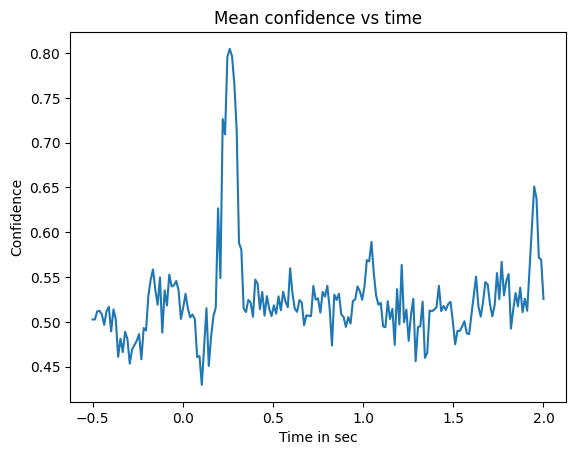

In [11]:
import matplotlib.pyplot as plt

time = np.linspace(-0.5, 2.0, n_time)

plt.figure()
plt.plot(time, np.nanmean(confidence, axis=0))
plt.xlabel("Time in sec")
plt.ylabel("Confidence")
plt.title("Mean confidence vs time")
plt.show()